In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange

class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [2]:
def dec(bits):
    return sum(int(bit) << i for i, bit in enumerate(np.round(bits, decimals=2)))

def tobin(x, size):
    x_bin = bin(x)[2:].zfill(size)
    x_bin = [int(bit) for bit in reversed(x_bin)]
    
    return np.array(x_bin)

In [3]:
def koggestone(a, b, size = 2):
    n = size

    P = mod2shallow(np.add(a, b))
    G = np.multiply(a, b)
    
    Pcopy = P.copy()
    
    step = 1
    
    while step < n:   
        G = G + P * np.roll(G, step)
        P = P * np.roll(P, step)
           
        step *= 2

    carry = np.roll(G, 1)
    
    S = (np.subtract(np.subtract(a, b) ** 2, carry) ** 2)
    
    return S

In [5]:
# This is the trigonometric polynomial that can be used for the bit decomposition of integers in [0, 225]

# Note: this has been normalized to work over [-1, 1] instead of [0, 225] to save one multiplication

def mod_reduction_norm(bit_position):
    period = 2**bit_position
    
    assert period % 2 == 0 and period >= 2
    P = period
    seq = np.array([0]*(P//2) + [1]*(P//2), dtype=float)

    c = np.fft.fft(seq) / P

    def f(x):
        x *= (128/2)
        x += 128/2
        s = c[0].real
        for k in range(1, P//2):
            ck = c[k]
            ang = 2 * math.pi * k * x / P
            s += 2 * (ck.real * math.cos(ang) - ck.imag * math.sin(ang))

        s += c[P//2].real * math.cos(math.pi * x)
        return s
    
    return f

In [7]:
a=-1
b=1

p1 = Chebyshev(a, b, 247, mod_reduction_norm(1))           # Period 2 {0, 1}
p2 = Chebyshev(a, b, 247, mod_reduction_norm(2))           # Period 4 {0, 0, 1, 1}
p3 = Chebyshev(a, b, 247, mod_reduction_norm(3))           # Period 8 {0, 0, 0, 0, 1, 1, 1, 1}
p4 = Chebyshev(a, b, 247, mod_reduction_norm(4))           # Period 16 
p5 = Chebyshev(a, b, 247, mod_reduction_norm(5))           # Period 32
p6 = Chebyshev(a, b, 247, mod_reduction_norm(6))           # Period 64
p7 = Chebyshev(a, b, 247, mod_reduction_norm(7))           # Period 128
p8 = Chebyshev(a, b, 247, mod_reduction_norm(8))           # Period 256

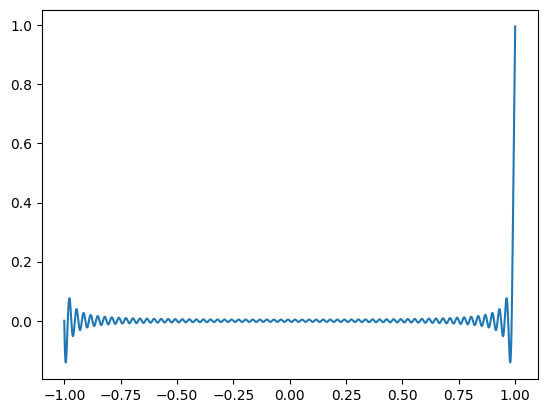

In [11]:
x = np.arange(-1, 1, 0.0001)

y = np.vectorize(p8.eval)(x)
y_real = np.vectorize(mod_reduction_norm(8))(x)

max(abs(y - y_real))

plt.plot(x, y)

In [ ]:
y

In [13]:
# Exporting them 
if True:
    with open("p1-norm-247-LUT-DIVISION.txt", "w") as f:
        f.write(", ".join(map(str, p1.c)))
    with open("p2-norm-247-LUT-DIVISION.txt", "w") as f:
        f.write(", ".join(map(str, p2.c)))
    with open("p3-norm-247-LUT-DIVISION.txt", "w") as f:
        f.write(", ".join(map(str, p3.c)))
    with open("p4-norm-247-LUT-DIVISION.txt", "w") as f:
        f.write(", ".join(map(str, p4.c)))
    with open("p5-norm-247-LUT-DIVISION.txt", "w") as f:
        f.write(", ".join(map(str, p5.c)))
    with open("p6-norm-247-LUT-DIVISION.txt", "w") as f:
        f.write(", ".join(map(str, p6.c)))
    with open("p7-norm-247-LUT-DIVISION.txt", "w") as f:
        f.write(", ".join(map(str, p7.c)))

In [91]:
import math

def simd_bintodec_tight(vec, rep):
    mask = np.array([])
    
    for i in range(rep):
        mask = np.append(mask, np.array([1, 2, 4, 8, 0, 0, 0, 0]))
    
    res = np.multiply(vec, mask)
    res = np.add(res, np.roll(res, -1))
    res = np.add(res, np.roll(res, -2))
    
    mask = np.array([])
    
    for i in range(rep):
        mask = np.append(mask, np.array([math.sqrt(1 / (225/2.0)), 0, 0, 0, 0, 0, 0, 0]))
        
    res = np.multiply(res, mask)
    res = np.add(res, np.roll(res, 1))
    res = np.add(res, np.roll(res, 2))
    res = np.add(res, np.roll(res, 4))

    return res

In [257]:
"""
Takes as input a repeated (8 times) vector containing the result of the computation
"""

def simd_4bits_multiplier_parallel(x, y, rep):
    res = np.multiply(x, y)
    res = res - 1

    for i in range(rep):
        res[i * 8 + 0] = p1.eval(res[i * 8 + 0])
        res[i * 8 + 1] = p2.eval(res[i * 8 + 1])
        res[i * 8 + 2] = p3.eval(res[i * 8 + 2])
        res[i * 8 + 3] = p4.eval(res[i * 8 + 3])
        res[i * 8 + 4] = p5.eval(res[i * 8 + 4])
        res[i * 8 + 5] = p6.eval(res[i * 8 + 5])
        res[i * 8 + 6] = p7.eval(res[i * 8 + 6])
        res[i * 8 + 7] = p8.eval(res[i * 8 + 7])
    
    return res

In [93]:
def mod2(x):
    return x**2*(x - 2)**2

def mod2shallow(x):
    return -x**2+2*x #(or reduce2)

def csa4(A, B, C, D, bits):
    """
    Somma 4 vettori di bit (LSB=0) usando CSA e Kogge-Stone finale
    add_koggestone(S2, C2_shift) deve restituire il numero finale corretto
    """
    S1, C1 = csa3_bits(A, B, C) 
    
    S2, C2 = csa3_bits(S1, C1, D)

    result = koggestone(S2, C2, bits)
    
    return result

def majority_bit_poly(a, b, c):
    """
    Calcola carry bit a bit usando operazioni aritmetiche
    Carry = 1 se almeno due bit sono 1
    """
    total = np.add(np.add(a, b), c)
    return (-1/3)*total**3 + (3/2)*total**2 - (7/6)*total


def csa3_bits(a, b, c):
    """
    CSA su 3 vettori di bit (LSB = indice 0)
    Restituisce (sum_bits, carry_bits)
    """
    S = mod2shallow(np.add(a, b))
    S = mod2shallow(np.add(S, c))
    
    C = majority_bit_poly(a, b, c)
    return S, roll_shift_left(C)

def roll_shift_left(bits):
    """Shift sinistra del carry, LSB diventa 0"""
    shifted = np.roll(bits, 1)
    #shifted[0] = 0
    return shifted

In [94]:
def process_array(data, processed, mask_roll_pairs, mask_size, rep):
    """
    Applies the mask-and-roll operations to a data array.
    
    Parameters:
    - data: np.array, the input array (a or b)
    - processed: np.array, the array to accumulate results into
    - mask_roll_pairs: list of tuples [(mask_start, roll_base), ...]
    - mask_size: int, the size of one repetition block
    - rep: int, number of repetitions
    """
    for start, roll_base in mask_roll_pairs:
        mask = np.zeros(mask_size * rep, dtype=int)
        for i in range(rep):
            mask[i * mask_size + start : i * mask_size + start + 4] = 1  # mask width always 4
        shift = roll_base - start
        processed += np.multiply(np.roll(data, shift), np.roll(mask, shift))
        #print(-shift, ",")
    return processed

In [95]:
# This is the optimized version of the multiplication, where only one multiplication 
# is done as part of the preprocessing

# For a more readable function, refer to "Plain framework (readabilty)"

def divideetimperamult(a, b, n, n_orig, rep = 1, rep_orig = 1):
    base_mult = 8
    
    rep_size = n**2 // 2
    
    if n == 8:
        mask_size = n_orig * (n_orig // 2)
        
        ### A ###
        
        masklow = np.zeros(len(a), dtype=int)
        for i in range(rep_orig): masklow[(i*mask_size):(i*mask_size)+4] = 1
        a_processed = np.multiply(a, masklow) 

        maskhigh = np.zeros(len(a), dtype=int)
        for i in range(rep_orig): maskhigh[(i*mask_size)+4:(i*mask_size)+8] = 1
        a_processed = np.add(a_processed, np.multiply(np.roll(a, 16-4), np.roll(maskhigh, 16-4)))

        if n_orig > 8: 
            a_processed = process_array(a, a_processed, [(8, 64), (12, 80)], mask_size, rep_orig)

        if n_orig > 16:  
            a_processed = process_array(a, a_processed, [(16, 256), (20, 272), (24, 320), (28, 336)], mask_size, rep_orig)

        if n_orig > 32: 
            a_processed = process_array(a, a_processed, [(32, 1024), (36, 1040), (40, 1088), (44, 1104), (48, 1280), (52, 1296), (56, 1344), (60, 1360)], mask_size, rep_orig)
        
        if n_orig > 64: 
            a_processed = process_array(a, a_processed, [(64, 4096), (68, 4112), (72, 4160), (76, 4176), (80, 4352), (84, 4368), (88, 4416), (92, 4432),(96, 5120), (100, 5136), (104, 5184), (108, 5200),(112, 5376), (116, 5392), (120, 5440), (124, 5456)], mask_size, rep_orig)

        if n_orig > 128: 
            a_processed = process_array(a, a_processed, [(128, 16384), (132, 16400), (136, 16448), (140, 16464), (144, 16640), (148, 16656), (152, 16704), (156, 16720), (160, 17408), (164, 17424), (168, 17472), (172, 17488), (176, 17664), (180, 17680), (184, 17728), (188, 17744), (192, 20480), (196, 20496), (200, 20544), (204, 20560), (208, 20736), (212, 20752), (216, 20800), (220, 20816), (224, 21504), (228, 21520), (232, 21568), (236, 21584), (240, 21760), (244, 21776), (248, 21824), (252, 21840)], mask_size, rep_orig)
            
        if (n_orig > 4): a_processed = np.add(a_processed, np.roll(a_processed, 8))
        if (n_orig > 8): a_processed = np.add(a_processed, np.roll(a_processed, 32))
        if (n_orig > 16): a_processed = np.add(a_processed, np.roll(a_processed, 128))
        if (n_orig > 32): a_processed = np.add(a_processed, np.roll(a_processed, 512))
        if (n_orig > 64): a_processed = np.add(a_processed, np.roll(a_processed, 2048))
        if (n_orig > 128): a_processed = np.add(a_processed, np.roll(a_processed, 8192))
        
        
        ### B ###
        
        b_processed = np.multiply(b, masklow)
        b_processed = np.add(b_processed, np.multiply(np.roll(b, 4), np.roll(maskhigh, 4)))

        if n_orig > 8:  # 16 bits
            b_processed = process_array(b, b_processed, [(8, 32), (12, 40)], mask_size, rep_orig)

        if n_orig > 16:  # 32 bits
            b_processed = process_array(b, b_processed, [(16, 128), (20, 136), (24, 160), (28, 168)], mask_size, rep_orig)

        if n_orig > 32:  # 64 bits
            b_processed = process_array(b, b_processed, [(32, 512), (36, 520), (40, 544), (44, 552), (48, 640), (52, 648), (56, 672), (60, 680)], mask_size, rep_orig)
        
        if n_orig > 64:  # 128 bits
            b_processed = process_array(b, b_processed, [(64, 2048), (68, 2056), (72, 2080), (76, 2088), (80, 2176), (84, 2184), (88, 2208), (92, 2216), (96, 2560), (100, 2568), (104, 2592), (108, 2600), (112, 2688), (116, 2696), (120, 2720), (124, 2728)], mask_size, rep_orig)

        if n_orig > 128:  # 256 bits
            b_processed = process_array(b, b_processed, [(128, 8192), (132, 8200), (136, 8224), (140, 8232), (144, 8320), (148, 8328), (152, 8352), (156, 8360), (160, 8704), (164, 8712), (168, 8736), (172, 8744), (176, 8832), (180, 8840), (184, 8864), (188, 8872), (192, 10240), (196, 10248), (200, 10272), (204, 10280), (208, 10368), (212, 10376), (216, 10400), (220, 10408), (224, 10752), (228, 10760), (232, 10784), (236, 10792), (240, 10880), (244, 10888), (248, 10912), (252, 10920)], mask_size, rep_orig)
    
        if (n_orig > 4): b_processed = np.add(b_processed, np.roll(b_processed, 16))
        if (n_orig > 8): b_processed = np.add(b_processed, np.roll(b_processed, 64))
        if (n_orig > 16): b_processed = np.add(b_processed, np.roll(b_processed, 256))
        if (n_orig > 32): b_processed = np.add(b_processed, np.roll(b_processed, 1024))
        if (n_orig > 64): b_processed = np.add(b_processed, np.roll(b_processed, 4096))
        if (n_orig > 128): b_processed = np.add(b_processed, np.roll(b_processed, 16384))
            
        
    if n == base_mult:
        mult = simd_4bits_multiplier_parallel(simd_bintodec_tight(a_processed, rep * 4), simd_bintodec_tight(b_processed, rep * 4), rep * 4)
    else:
        mult = divideetimperamult(a, b, n//2, n_orig, 4 * rep, rep_orig)

    dunn = (n**2 // base_mult) * 2
    
    mask1 = np.zeros(len(a), dtype=float)
    for j in range(rep):
        for i in range(n):
            mask1[(j * rep_size) + i] = 1
            mask1[(j * rep_size) + i + dunn] = 1
            
    p1 = np.multiply(mult, mask1)
    p2 = np.roll(p1, -rep_size//2 + n//2)
    
    mask2 = np.zeros(len(a), dtype=float)
    for j in range(rep):
        for i in range(n):
            mask2[(j * rep_size) + rep_size // 4 + i] = 1
            mask2[(j * rep_size) + rep_size // 4 + i + dunn] = 1
    
    if n == 8:
        p3 = np.roll(np.multiply(mult, mask2), -16)
    else:
        p3 = np.roll(np.multiply(mult, mask2), -rep_size // 4 + n//2)

    if n == 8:
        p4 = np.roll(p3, 12)
    else:
        shift = ((n - 2) * (3*n - 2)) // 8
        p4 = np.roll(np.multiply(mult, mask2), -shift)
    
    
    if n == n_orig:
        # If one want the original product modulo 2^(2n) (although requiring twice the CKKS slots),
        # simply use the following line:
        
        # return csa4(p1, p2, p3, p4, n)
        
        # Otherwise, return the product mod 2^n:
        S, C = csa3_bits(p1, p2, p3)
        return koggestone(S, C, n)
    else:
        return csa4(p1, p2, p3, p4, n)

In [256]:
# Use bits = 8, 16, 32, 64, 128 or 256

bits = 128

In [253]:
x = randrange(2**bits)
y = randrange(2**bits)

print("x:", x)
print("y:", y)
print("resulting bits:", (x*y).bit_length())

x: 46127291556847031283461186211988792682
y: 135054267807532574464981323189325082215
resulting bits: 252


In [254]:
print("x + y (real)   :", x + y)
print("x + y (binary) :", dec(koggestone(tobin(x, bits*bits//2), tobin(y, bits*bits//2), bits)[:bits+1]))

x + y (real)   : 181181559364379605748442509401313874897
x + y (binary) : 181181559364379605748442509401313874897


In [260]:
print("x * y (real)   :", (x * y) % 2**bits)
print("x * y (binary) :", dec(divideetimperamult(tobin(x, bits*bits//2), tobin(y, bits*bits//2), bits, bits, 1, 1)[:bits]))

x * y (real)   : 309772196167501570127497824628478171558
x * y (binary) : 309772196167501570127497824628478171558


In [259]:
print("x <= y (real)   :", x <= y)
print("x <= y (binary) :", koggestone(tobin(x, bits*bits//2), 1-tobin(y, bits*bits//2), bits)[bits])

x <= y (real)   : True
x <= y (binary) : 1


---

### Batched

In [76]:
x = np.array([])
y = np.array([])

x_plain = []
y_plain = []

batch = 8

for i in range(batch):
    x_plain.append(randrange(2**bits))
    y_plain.append(randrange(2**bits))
    
    x = np.concatenate((x, tobin(x_plain[i], bits*bits//2)))
    y = np.concatenate((y, tobin(y_plain[i], bits*bits//2)))

bin_add = koggestone(x, y, bits)
bin_mul = divideetimperamult(x, y, bits, bits, batch, batch)



for i in range(batch):
    print(f"x_{i} + y_{i} (real)   :", x_plain[i] + y_plain[i])
    print(f"x_{i} + y_{i} (binary) :", dec(bin_add[bits*bits//2*i:bits*bits//2*i+bits+1]))
    print(f"x_{i} * y_{i} (real)   :", (x_plain[i] * y_plain[i]) % 2**bits)
    print(f"x_{i} * y_{i} (binary) :", dec(bin_mul[bits*bits//2*i:bits*bits//2*i+bits]))
    print("------------")

x_0 + y_0 (real)   : 430795824339087372261805644462998729995
x_0 + y_0 (binary) : 430795824339087372261805644462998729995
x_0 * y_0 (real)   : 143330487162243291532444606924473307662
x_0 * y_0 (binary) : 143330487162243291532444606924473307662
------------
x_1 + y_1 (real)   : 310923513614514990050168420627167273751
x_1 + y_1 (binary) : 310923513614514990050168420627167273751
x_1 * y_1 (real)   : 180030686200901002959817643086105211248
x_1 * y_1 (binary) : 180030686200901002959817643086105211248
------------
x_2 + y_2 (real)   : 465122888323085121528428749674485242895
x_2 + y_2 (binary) : 465122888323085121528428749674485242895
x_2 * y_2 (real)   : 302247308407388251307639195986007924176
x_2 * y_2 (binary) : 302247308407388251307639195986007924176
------------
x_3 + y_3 (real)   : 211813588378297373964416616165047212606
x_3 + y_3 (binary) : 211813588378297373964416616165047212606
x_3 * y_3 (real)   : 157808067346824074088550082596049407824
x_3 * y_3 (binary) : 1578080673468240740885500